# 03 — Concisão (tamanho e foco da resposta)

**Pergunta principal:** *quem responde direto ao ponto, e quanto isso custa em precisão?*

A coluna `concisao_score` foi atribuída por um juiz LLM dedicado, no espírito:
- **1** = resposta vai direto ao que foi perguntado;
- **0** = resposta despeja informação não pedida ou se estende muito.

A coluna `justificativa_concisao` traz a justificativa textual em cada caso.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from utils import (
    carregar_dados, estilo_padrao,
    ORDEM_MODELOS, CORES_FAMILIA, FAMILIA, MODELO_DISPLAY,
    titulo_acima, rotulos_em_cima,
)

estilo_padrao()
df = carregar_dados()

## 1. Ranking de concisão

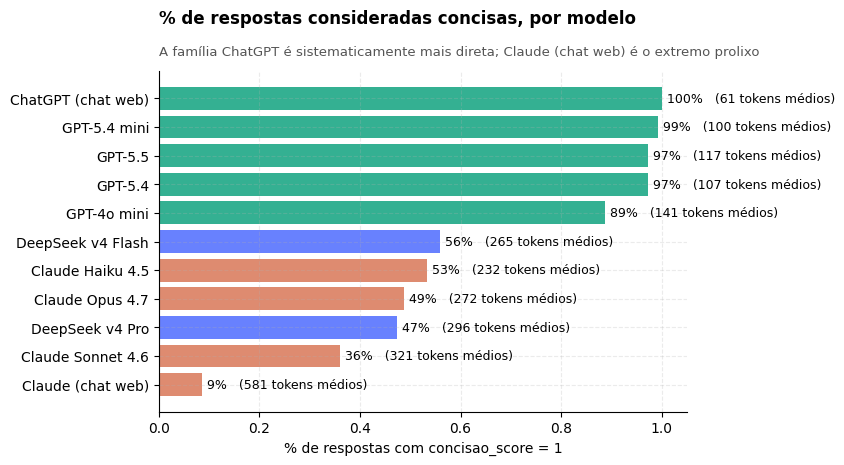

In [2]:
rank = (df.groupby('modelo_display')
          .agg(concisao=('concisao_score','mean'),
               tokens=('resposta_tokens_tiktoken','mean'),
               n=('id','count'))
          .loc[ORDEM_MODELOS]
          .sort_values('concisao'))

cores = [CORES_FAMILIA[FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]]
         for m in rank.index]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
y = np.arange(len(rank))
ax.barh(y, rank['concisao'], color=cores, alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(rank.index)
ax.set_xlim(0, 1.05)

for i, (v, t) in enumerate(zip(rank['concisao'], rank['tokens'])):
    ax.text(v + 0.01, i, f'{v*100:.0f}%   ({t:.0f} tokens médios)',
            va='center', fontsize=9)

titulo_acima(ax,
    '% de respostas consideradas concisas, por modelo',
    'A família ChatGPT é sistematicamente mais direta; Claude (chat web) é o extremo prolixo')
ax.set_xlabel('% de respostas com concisao_score = 1')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

**O contraste é gritante:**
- `ChatGPT (chat web)` é considerado conciso em **100%** das respostas (média de 61 tokens).
- `Claude (chat web)` cai para **9%** (média de 581 tokens — quase 10× maior).
- Entre as ferramentas, a família OpenAI continua mais enxuta (~97-99%); Claude/DeepSeek ficam abaixo de 60%.


## 2. Relação entre tamanho da resposta e concisão  *(por modelo)*

A concisão é só uma medida de "respostas mais curtas"? Aqui agregamos **um ponto por modelo** — `tokens_media` é a média de `resposta_tokens_tiktoken` do modelo, `taxa_foco` é a proporção de respostas com `concisao_score = 1`. Ao agregar, a variância individual de cada resposta desaparece e a relação estrutural entre os modelos fica nítida.

> Importante: aqui a unidade é **modelo**, não **resposta**. A correlação por ocorrência (linha a linha) é mais fraca, porque cada modelo tem alta variância interna.

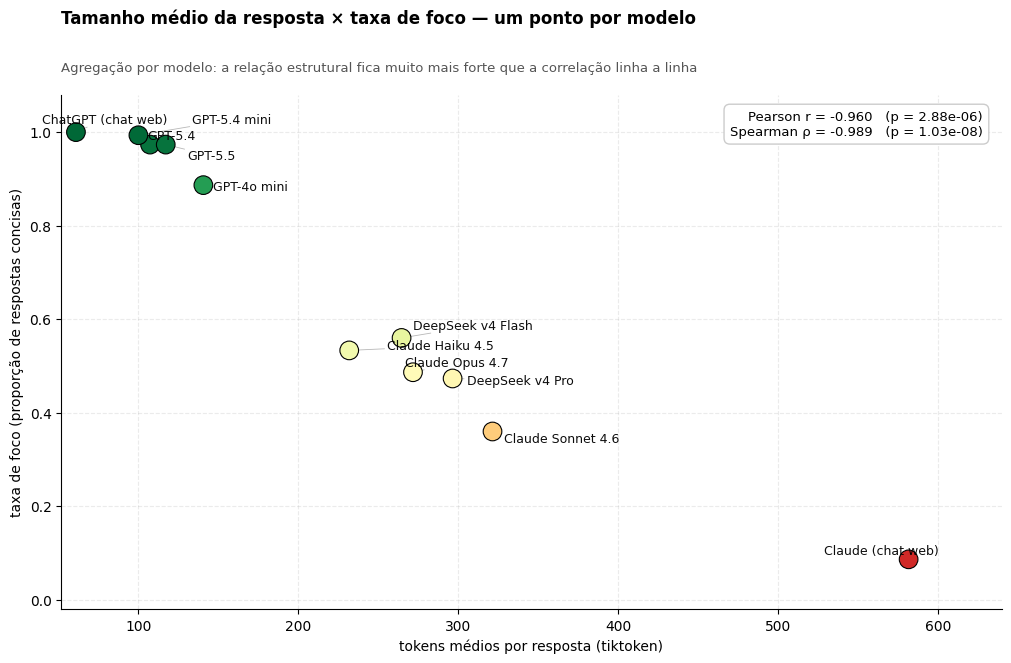

,tokens_media,taxa_foco,familia,n
modelo_display,,,,
ChatGPT (chat web),61.100,1.000,OpenAI,150
Claude (chat web),581.413,0.087,Claude,150
Claude Haiku 4.5,231.860,0.533,Claude,150
Claude Opus 4.7,271.707,0.487,Claude,150
Claude Sonnet 4.6,321.400,0.360,Claude,150
DeepSeek v4 Flash,264.573,0.560,DeepSeek,150
DeepSeek v4 Pro,296.453,0.473,DeepSeek,150
GPT-4o mini,140.720,0.887,OpenAI,150
GPT-5.4,107.413,0.973,OpenAI,150


In [3]:
from scipy import stats

tabela_modelo = (df.groupby('modelo_display')
                   .agg(tokens_media=('resposta_tokens_tiktoken','mean'),
                        taxa_foco=('concisao_score','mean'),
                        familia=('familia','first'),
                        n=('id','count')))

x = tabela_modelo['tokens_media']
y = tabela_modelo['taxa_foco']
r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(10, 6.5), layout='constrained')

# Bolinha colorida pelo próprio valor de foco — verde = conciso, vermelho = prolixo
sc = ax.scatter(x, y, s=180, c=y, cmap='RdYlGn', vmin=0, vmax=1,
                edgecolors='black', linewidths=0.8, zorder=3)

# Anotações sem sobreposição (adjustText quando disponível)
try:
    from adjustText import adjust_text
    texts = [ax.text(xi, yi, m, fontsize=9, alpha=0.95)
             for xi, yi, m in zip(x, y, tabela_modelo.index)]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.6, alpha=0.6),
                expand=(1.2, 1.6))
except ImportError:
    print('Para anotações sem sobreposição:  pip install adjustText')
    for xi, yi, m in zip(x, y, tabela_modelo.index):
        ax.annotate(m, (xi, yi), xytext=(7, 4),
                    textcoords='offset points', fontsize=8.5)

ax.set_xlim(x.min() * 0.85, x.max() * 1.10)
ax.set_ylim(-0.02, 1.08)
ax.set_xlabel('tokens médios por resposta (tiktoken)')
ax.set_ylabel('taxa de foco (proporção de respostas concisas)')

# Estatísticas no canto, sem caixa pesada
ax.text(0.98, 0.97,
        f'Pearson r = {r_p:.3f}   (p = {p_p:.2e})\n'
        f'Spearman ρ = {r_s:.3f}   (p = {p_s:.2e})',
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#ccc'))

titulo_acima(ax,
    'Tamanho médio da resposta × taxa de foco — um ponto por modelo',
    'Agregação por modelo: a relação estrutural fica muito mais forte que a correlação linha a linha')

plt.show()

# Para inspeção
tabela_modelo.round(3)

A correlação é forte (**-0.68**), mas não perfeita: há respostas curtas julgadas como não-concisas (despejaram lista enumerada quando a pergunta era binária) e respostas longas julgadas concisas (a pergunta exigia narrativa). O juiz não está só medindo tamanho — está medindo **aderência à pergunta**.

> Isso justifica manter `concisao_score` como métrica própria em vez de só usar contagem de tokens.


## 3. Trade-off precisão × concisão

Aqui está o gráfico que separa os modelos de verdade.


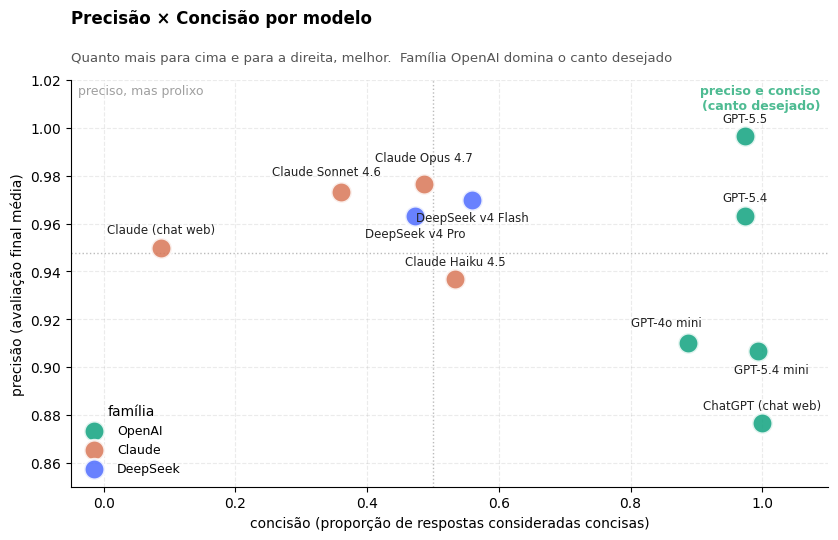

In [4]:
agg = (df.groupby('modelo_display')
         .agg(precisao=('avaliacao_final','mean'),
              concisao=('concisao_score','mean'),
              familia=('familia','first'))
         .loc[ORDEM_MODELOS])

fig, ax = plt.subplots(figsize=(8.5, 6))

for fam in CORES_FAMILIA:
    sub = agg[agg['familia'] == fam]
    ax.scatter(sub['concisao'], sub['precisao'], s=220, alpha=0.85,
               c=CORES_FAMILIA[fam], edgecolor='white', linewidth=2,
               label=fam, zorder=3)

offsets = {
    'Claude Opus 4.7':   (0,  14),
    'DeepSeek v4 Flash': (0, -18),
    'Claude Sonnet 4.6': (-10, 10),
    'DeepSeek v4 Pro':   (0, -18),
    'GPT-4o mini':   (-15, 10),
    'GPT-5.4 mini':  (10, -18),
}
rotulos_em_cima(ax, agg['concisao'], agg['precisao'], agg.index,
                fontsize=8.5, offsets=offsets)

# Quadrantes
mid_x, mid_y = 0.5, agg['precisao'].mean()
ax.axhline(mid_y, color='#bbb', ls=':', lw=1, zorder=1)
ax.axvline(mid_x, color='#bbb', ls=':', lw=1, zorder=1)
ax.text(0.99, 0.99, 'preciso e conciso\n(canto desejado)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='#2a7', alpha=0.8, weight='bold')
ax.text(0.01, 0.99, 'preciso, mas prolixo',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color='#888', alpha=0.8)

titulo_acima(ax,
    'Precisão × Concisão por modelo',
    'Quanto mais para cima e para a direita, melhor.  Família OpenAI domina o canto desejado')
ax.set_xlabel('concisão (proporção de respostas consideradas concisas)')
ax.set_ylabel('precisão (avaliação final média)')
ax.set_xlim(-0.05, 1.10)
ax.set_ylim(0.85, 1.02)
ax.legend(title='família', loc='lower left')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

**O que esse gráfico diz que os outros não dizem:**

- **GPT 5.5 está sozinho.** É o único modelo que combina precisão máxima (≈ 1,00) com concisão muito alta (97%).
- A família **Claude (ferramenta)** entrega precisão equivalente, mas cai para 35-55% de concisão. Quem entrega o conteúdo final para um usuário leigo precisa pensar nisso.
- **DeepSeek v4 Flash** consegue precisão alta a custo baixíssimo (próximo notebook), mas é prolixo (56% conciso).
- O canto inferior-esquerdo está vazio — não há modelo "ruim em tudo", o que era esperado dado que todos passam de 87% em precisão.

Esse trade-off é o que justifica o `05_sintese.ipynb` precisar combinar essas duas dimensões com custo numa decisão final.
